In [1]:
import pathlib
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr

In [2]:
overpass_path = pathlib.Path("/work/scratch-nopw2/wkjones/ec_track_overpasses")
overpass_files = sorted(list(overpass_path.glob("*.nc")))

In [3]:
slice_save_path = pathlib.Path("/work/scratch-nopw2/wkjones/ec_anvil_overpasses/")
slice_save_path.mkdir(exist_ok=True)

In [4]:
tracking_path = pathlib.Path("/gws/ssde/j25a/esaclim/will/orcestra_linked")

In [5]:
tracking_files = sorted(list(tracking_path.rglob("detected_dccs_*.nc")))

In [6]:
tracks_ds = xr.open_dataset(tracking_files[8])

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'datamet' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
 

In [11]:
tracks_ds

<xarray.Dataset> Size: 19GB
Dimensions:                       (y: 2287, x: 3623, t: 96, core: 2541,
                                   anvil: 1720, core_step: 11230,
                                   thick_anvil_step: 29326,
                                   thin_anvil_step: 32808)
Coordinates:
  * t                             (t) datetime64[ns] 768B 2024-08-18T00:12:43...
  * y                             (y) float64 18kB -3.429e+06 ... 3.429e+06
  * x                             (x) float64 29kB 5.434e+06 ... -5.434e+06
    longitude                     (y, x) float64 66MB ...
    latitude                      (y, x) float64 66MB ...
  * core                          (core) int32 10kB 27858 27862 ... 30466 30467
  * anvil                         (anvil) int32 7kB 11702 11709 ... 13958 13964
  * core_step                     (core_step) int32 45kB 1 2 3 ... 11229 11230
  * thick_anvil_step              (thick_anvil_step) int32 117kB 1 2 ... 29326
  * thin_anvil_step               (thin_anvil_step) int32 131kB 1 2 ... 32808
Data variables: (12/77)
    lat                           (y, x) float32 33MB ...
    lon                           (y, x) float32 33MB ...
    area                          (y, x) float32 33MB ...
    core_label                    (t, y, x) int32 3GB ...
    thick_anvil_label             (t, y, x) int32 3GB ...
    thin_anvil_label              (t, y, x) int32 3GB ...
    ...                            ...
    thick_anvil_step_bt_max       (thick_anvil_step) float32 117kB ...
    thick_anvil_step_bt_min       (thick_anvil_step) float32 117kB ...
    thin_anvil_step_bt_mean       (thin_anvil_step) float32 131kB ...
    thin_anvil_step_bt_std        (thin_anvil_step) float32 131kB ...
    thin_anvil_step_bt_max        (thin_anvil_step) float32 131kB ...
    thin_anvil_step_bt_min        (thin_anvil_step) float32 131kB ...

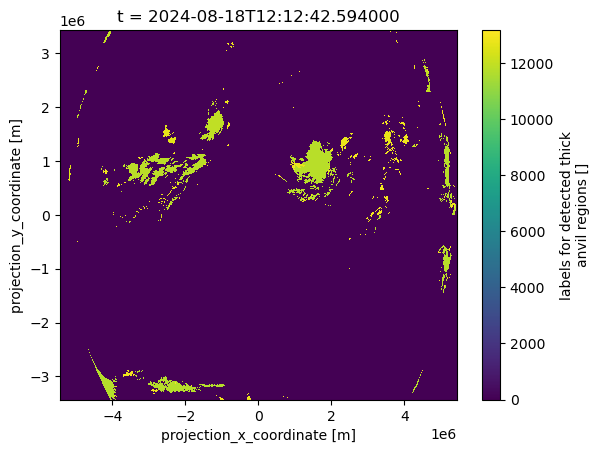

In [8]:
tracks_ds.thick_anvil_label[48].plot()

In [9]:
stats_path = pathlib.Path("/gws/ssde/j25a/esaclim/will")
stats_file = list(stats_path.glob("*_S20240810*"))[0]
stats_ds = xr.open_dataset(stats_file)

In [10]:
stats_ds

<xarray.Dataset> Size: 245MB
Dimensions:                                      (anvil: 58592,
                                                  thick_anvil_step: 1151260,
                                                  core_step: 950514,
                                                  thin_anvil_step: 1249512,
                                                  core: 212782)
Coordinates:
  * anvil                                        (anvil) int32 234kB 12 ... 9...
  * core_step                                    (core_step) int32 4MB 6 ... ...
  * thick_anvil_step                             (thick_anvil_step) int32 5MB ...
  * thin_anvil_step                              (thin_anvil_step) int32 5MB ...
  * core                                         (core) int32 851kB 119 ... 2...
    y_image                                      int64 8B ...
    x_image                                      int64 8B ...
Data variables: (12/144)
    thin_anvil_end_label_flag                    (anvil) bool 59kB ...
    thick_anvil_step_t                           (thick_anvil_step) datetime64[ns] 9MB ...
    core_step_core_index                         (core_step) int32 4MB ...
    thick_anvil_step_bt_std                      (thick_anvil_step) float32 5MB ...
    thin_anvil_step_anvil_index                  (thin_anvil_step) int32 5MB ...
    core_end_label_flag                          (core) bool 213kB ...
    ...                                           ...
    anvil_no_growth_flag                         (anvil) bool 59kB ...
    anvil_no_initial_core_flag                   (anvil) bool 59kB ...
    core_is_valid                                (core) bool 213kB ...
    anvil_invalid_core_flag                      (anvil) bool 59kB ...
    thick_anvil_is_valid                         (anvil) bool 59kB ...
    thin_anvil_is_valid                          (anvil) bool 59kB ...

In [23]:
stats_ds.core

<xarray.DataArray 'core' (core: 212782)> Size: 851kB
array([   119,    129,    148, ..., 215200, 215201, 215202], dtype=int32)
Coordinates:
  * core     (core) int32 851kB 119 129 148 150 ... 215199 215200 215201 215202
    y_image  int64 8B ...
    x_image  int64 8B ...

In [30]:
stats_ds.anvil[10000]

<xarray.DataArray 'anvil' ()> Size: 4B
array(18368, dtype=int32)
Coordinates:
    anvil    int32 4B 18368
    y_image  int64 8B ...
    x_image  int64 8B ...

In [33]:
stats_ds.thin_anvil_is_valid[10001].item()

True

In [34]:
stats_ds.anvil[10001]

<xarray.DataArray 'anvil' ()> Size: 4B
array(18373, dtype=int32)
Coordinates:
    anvil    int32 4B 18373
    y_image  int64 8B ...
    x_image  int64 8B ...

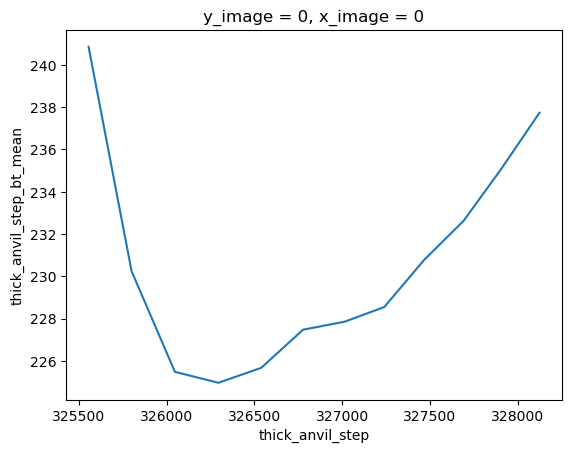

In [35]:
stats_ds.isel(thick_anvil_step=stats_ds.thick_anvil_step_anvil_index==18373).thick_anvil_step_bt_mean.plot()

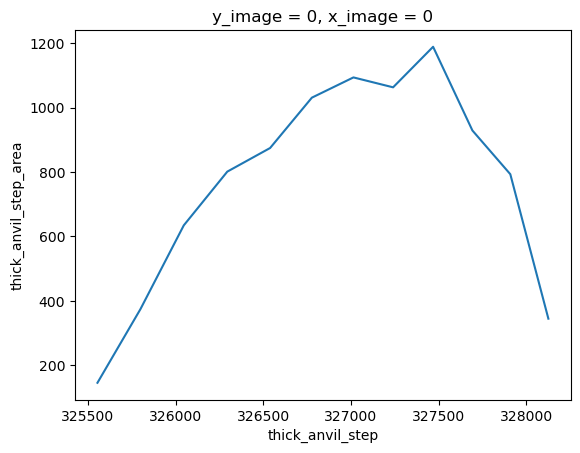

In [36]:
stats_ds.isel(thick_anvil_step=stats_ds.thick_anvil_step_anvil_index==18373).thick_anvil_step_area.plot()

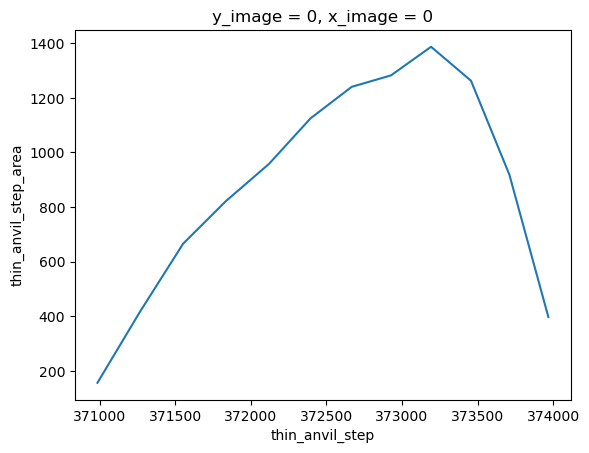

In [37]:
stats_ds.isel(thin_anvil_step=stats_ds.thin_anvil_step_anvil_index==18373).thin_anvil_step_area.plot()

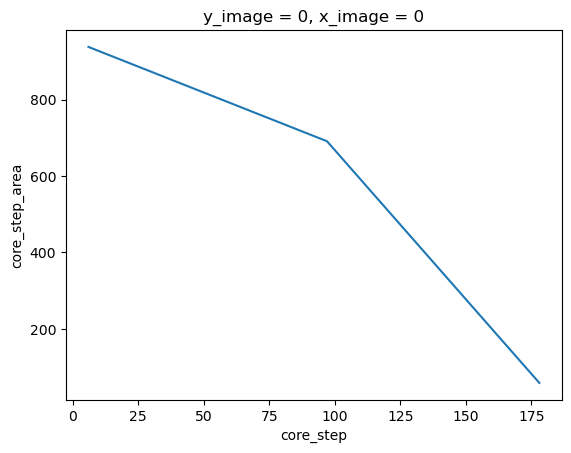

In [27]:
stats_ds.isel(core_step=stats_ds.core_step_core_index==119).core_step_area.plot()

In [22]:
stats_ds.core_step_bt

<xarray.DataArray 'core_step_core_index' (core_step: 950514)> Size: 4MB
[950514 values with dtype=int32]
Coordinates:
  * core_step  (core_step) int32 4MB 6 11 17 19 ... 956276 956277 956278 956279
    y_image    int64 8B ...
    x_image    int64 8B ...

In [17]:
xr.open_datatree(overpass_files[-1])

<xarray.DataTree>
Group: /
│   Dimensions:            (along_track: 8465, height: 200)
│   Coordinates:
│       time               (along_track) datetime64[ns] 68kB ...
│       latitude           (along_track) float64 68kB ...
│       longitude          (along_track) float64 68kB ...
│     * height             (height) float64 2kB 1.995e+04 1.985e+04 ... 150.0 50.0
│   Dimensions without coordinates: along_track
│   Data variables:
│       core_label         (along_track) int32 34kB ...
│       thick_anvil_label  (along_track) int32 34kB ...
│       thin_anvil_label   (along_track) int32 34kB ...
│   Attributes:
│       granules:              01713H 01714A 01714B
│       track_mask_filenames:  detected_dccs_MSG_S20240916_000000_E20240917_00000...
├── Group: /AC__TC__2B
│       Dimensions:                           (along_track: 8465, height: 200)
│       Coordinates:
│           time                              (along_track) datetime64[ns] 68kB ...
│           latitude                          (along_track) float64 68kB ...
│           longitude                         (along_track) float64 68kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           synergetic_target_classification  (along_track, height) float64 14MB ...
│           CPR_ATLID_status                  (along_track, height) float64 14MB ...
│           quality_status                    (along_track, height) float64 14MB ...
│       Attributes:
│           File_Name:         ECA_EXBA_AC__TC__2B_20240916T022038Z_20250906T234936Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         AC__TC__2B
│           File_Version:      0001
├── Group: /ACM_CAP_2B
│       Dimensions:                                     (along_track: 8465, height: 200)
│       Coordinates:
│           time                                        (along_track) datetime64[ns] 68kB ...
│           latitude                                    (along_track) float64 68kB ...
│           longitude                                   (along_track) float64 68kB ...
│       Dimensions without coordinates: along_track
│       Data variables: (12/50)
│           tropopause_height                           (along_track) float32 34kB ...
│           synergy_status                              (along_track) float32 34kB ...
│           quality_status                              (along_track) float32 34kB ...
│           ice_extinction                              (along_track, height) float32 7MB ...
│           ice_riming_index                            (along_track, height) float32 7MB ...
│           ice_riming_index_error                      (along_track, height) float32 7MB ...
│           ...                                          ...
│           aerosol_mass_content_error                  (along_track, height) float32 7MB ...
│           aerosol_extinction                          (along_track, height) float32 7MB ...
│           aerosol_extinction_error                    (along_track, height) float32 7MB ...
│           aerosol_optical_depth                       (along_track) float32 34kB ...
│           aerosol_optical_depth_error                 (along_track) float32 34kB ...
│           CPR_doppler_velocity                        (along_track, height) float32 7MB ...
│       Attributes:
│           File_Name:         ECA_EXBA_ACM_CAP_2B_20240916T022038Z_20250908T001938Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         ACM_CAP_2B
│           File_Version:      0001
├── Group: /ACM_RT__2B
│       Dimensions:                                      (along_track: 8465,
│                                                         atmosphere_1d: 1,
│                                                         he

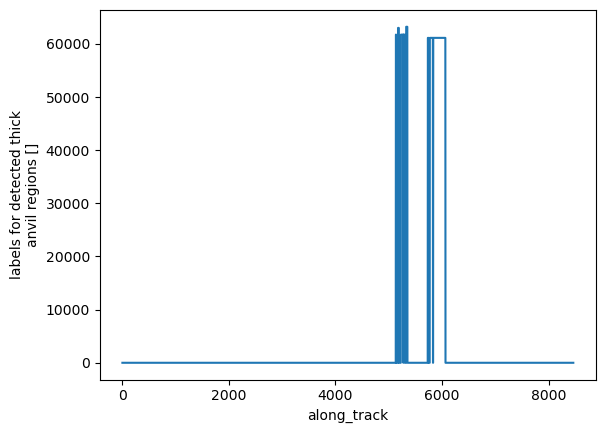

In [15]:
xr.open_datatree(overpass_files[-1]).thick_anvil_label.plot()

In [19]:
slice_files = sorted(list(slice_save_path.glob("*.nc")))

In [21]:
xr.open_datatree(slice_files[-1]).load()

<xarray.DataTree>
Group: /
│   Dimensions:                (along_track: 262, height: 200)
│   Coordinates:
│       time                   (along_track) datetime64[ns] 2kB 2024-09-14T14:20:...
│       latitude               (along_track) float64 2kB 11.56 11.55 ... 9.157 9.148
│       longitude              (along_track) float64 2kB -3.258 -3.26 ... -3.718
│     * height                 (height) float64 2kB 1.995e+04 1.985e+04 ... 50.0
│   Dimensions without coordinates: along_track
│   Data variables: (12/14)
│       core_label             (along_track) int32 1kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       thick_anvil_label      (along_track) int32 1kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       thin_anvil_label       (along_track) int32 1kB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0
│       anvil_id               int32 4B 59687
│       anvil_is_valid         <U5 20B 'False'
│       mean_overpass_time     <U29 116B '2024-09-14T14:20:20.348023088'
│       ...                     ...
│       anvil_core_count       int64 8B 19
│       anvil_core_intensity   float64 8B 1.486
│       anvil_max_area         float64 8B 2.436e+04
│       anvil_min_bt           float64 8B 192.3
│       anvil_lifetime_stage   <U7 28B 'growing'
│       min_overpass_distance  float64 8B 35.65
│   Attributes:
│       granules:              01690D 01690E 01690F
│       track_mask_filenames:  detected_dccs_MSG_S20240914_000000_E20240915_00000...
│       stats_file:            dcc_statistics_orcestra_S20240810_000000_E20241001...
├── Group: /AC__TC__2B
│       Dimensions:                           (along_track: 262, height: 200)
│       Coordinates:
│           time                              (along_track) datetime64[ns] 2kB 2024-0...
│           latitude                          (along_track) float64 2kB 11.56 ... 9.148
│           longitude                         (along_track) float64 2kB -3.258 ... -3...
│       Dimensions without coordinates: along_track
│       Data variables:
│           synergetic_target_classification  (along_track, height) float64 419kB 29....
│           CPR_ATLID_status                  (along_track, height) float64 419kB 5.0...
│           quality_status                    (along_track, height) float64 419kB 4.3...
│       Attributes:
│           File_Name:         ECA_EXBA_AC__TC__2B_20240914T140522Z_20250906T233615Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         AC__TC__2B
│           File_Version:      0001
├── Group: /ACM_CAP_2B
│       Dimensions:                                     (along_track: 262, height: 200)
│       Coordinates:
│           time                                        (along_track) datetime64[ns] 2kB ...
│           latitude                                    (along_track) float64 2kB 11....
│           longitude                                   (along_track) float64 2kB -3....
│       Dimensions without coordinates: along_track
│       Data variables: (12/50)
│           tropopause_height                           (along_track) float32 1kB 1.7...
│           synergy_status                              (along_track) float32 1kB 0.0...
│           quality_status                              (along_track) float32 1kB 0.0...
│           ice_extinction                              (along_track, height) float32 210kB ...
│           ice_riming_index                            (along_track, height) float32 210kB ...
│           ice_riming_index_error                      (along_track, height) float32 210kB ...
│           ...                                          ...
│           aerosol_mass_content_error                  (along_track, height) float32 210kB ...
│           aerosol_extinction                          (along_track, height) float32 210kB ...
│           aerosol_extinction_error                    (along_track, height) float32 210kB ...
│           aerosol_optical_depth         